# Reimagining Downtown Winnipeg: A $2.3B Transition From Retail to Residential (2010–2026)
**Stakeholder Report**

**Author:** Troy Dela Rosa  
**Date:** April 19, 2026

*A plain-language look at what the data actually says about downtown Winnipeg from 2010 to 2026.*

## Executive Summary

If you live in Winnipeg, you've probably heard two very different stories about downtown. One says it's failing — empty offices, closed stores, not safe. The other says it's on the edge of a comeback — $2.3 billion in investment, new housing, big redevelopment projects.

After digging into the data, I think both stories are partly right and both are partly wrong. Here's the short version of what I found:

- **Office vacancy nearly doubled** between 2016 and 2025, from about 8.7% to 18.6%.
- **Retail activity dropped by roughly 63%** compared to its 2013 level.
- **Food and services businesses are bouncing back** faster than any other sector.
- **Most of the $2.3 billion in investment has not been delivered yet** — it's still under construction or in planning.
- The shape of downtown is changing from an office-and-shopping area into a **residential and institutional** area.

The most honest description of downtown Winnipeg right now isn't "declining" or "recovering." It's **in the middle of a conversion**, and the results won't be visible on the street for another two or three years.

## 1. Why I Looked at This

I wanted to know whether downtown Winnipeg is actually declining, or whether something more complicated is happening. My instructor pointed out early on that looking at only the last three years wouldn't tell me much -  short-term numbers bounce around too much to reveal a real trend. So I pushed the timeline back to 2010 and pulled together data from several public sources.

This report walks through what the data shows, section by section, in plain language. Every chart is labelled so you can tell whether it comes from directly observed records or from reconstructed estimates.

**The central question:** Is downtown failing, or is it turning into something different?

## 2. Where the Data Comes From

I used five datasets, all from public sources:

- **City of Winnipeg business licenses** (2021–2026) — the core record of who is open for business downtown.
- **A structural events timeline** — 28 major downtown projects, closures, and policy decisions I compiled from CBRE reports, Downtown Winnipeg BIZ snapshots, and CBC Manitoba reporting.
- **A housing pipeline dataset** — residential projects either completed, under construction, or planned.
- **A reconstructed business activity model** for 2010–2020, built because the City's open-data portal doesn't go back that far.
- **A source registry** that documents every figure in this report with its origin and reliability rating.

**How confident can you be in each number?** Every chart is tagged with one of four labels:

| Tag | What it means |
|---|---|
| `[L1 - OBSERVED]` | Confirmed from primary sources |
| `[L2 - RECONSTRUCTED]` | Estimated to fill in known data gaps |
| `[L3 - INFERRED]` | A pattern derived from the data, not a direct measurement |
| `[L4 - SCENARIO]` | A model output based on stated assumptions |

## 3. Setup

In [1]:
# Standard data and plotting imports
import sys
import importlib
import pandas as pd
import matplotlib.pyplot as plt

# Bring in the helper module (all cleaning and plotting logic lives there)
sys.path.insert(0, '..')
import src.helpers
importlib.reload(src.helpers)

from src.helpers import (
    clean_column_names, filter_downtown,
    clean_gantt, clean_housing, clean_business_licenses,
    compute_phase_composition, plot_phase_composition,
    prepare_business_activity_index_data, plot_business_activity_index,
    prepare_vacancy_benchmark_data, plot_vacancy_benchmark,
    prepare_residential_pipeline_plot_data, plot_residential_pipeline,
    prepare_investment_scale_data, plot_investment_scale,
    compute_dhs,
)

# Dark chart theme — applied once, inherited by every chart
plt.rcParams.update({
    'figure.facecolor': '#0d0f14', 'axes.facecolor': '#161921',
    'axes.edgecolor':   '#2a2e3a', 'axes.labelcolor': '#e0ddd5',
    'text.color':       '#e0ddd5', 'xtick.color': '#8a8780',
    'ytick.color':      '#8a8780', 'grid.color': '#2a2e3a',
    'font.family': 'sans-serif', 'font.size': 11, 'figure.dpi': 120,
})

# Chart colours
GROWTH_C, TRANS_C = '#4e9a6e', '#5a7bbf'

print("Ready.")

Ready.


All heavy lifting -  cleaning, filtering, plotting - lives in the `helpers` module so this notebook stays focused on the story rather than the code.

## 4. Load and Clean the Data

One cell loads every dataset this report needs and hands back clean, ready-to-use tables.

In [2]:
# Load raw files
gantt_raw   = pd.read_csv('../data/downtown_wpg_gantt_sourced_2026.csv')
housing_raw = pd.read_csv('../data/housing_pipeline_2026.csv', encoding='utf-8-sig')
biz_raw     = pd.read_csv('../data/Business_Licenses_20260404.csv',
                          encoding='cp1252', low_memory=False)

# Clean each one using the helper module
gantt                  = clean_gantt(gantt_raw)
housing, housing_model = clean_housing(housing_raw)
biz                    = clean_business_licenses(filter_downtown(clean_column_names(biz_raw)))

print(f"Structural events:  {len(gantt)} rows")
print(f"Housing projects:   {len(housing)} rows ({len(housing_model)} model-ready)")
print(f"Downtown licenses:  {len(biz)} rows")

Structural events:  30 rows
Housing projects:   8 rows (7 model-ready)
Downtown licenses:  2231 rows


## 5. What the Data Shows

Five charts, one idea each. I've put the takeaway first and the chart underneath.

### 5.1 The Type of Activity Downtown Changed `[OBSERVED]`

**Takeaway:** Downtown has moved through three phases since 2010. The current phase, starting around 2020, has the highest number of major events and the largest share of growth-type investment - but most of that activity is still *in progress*, not delivered.

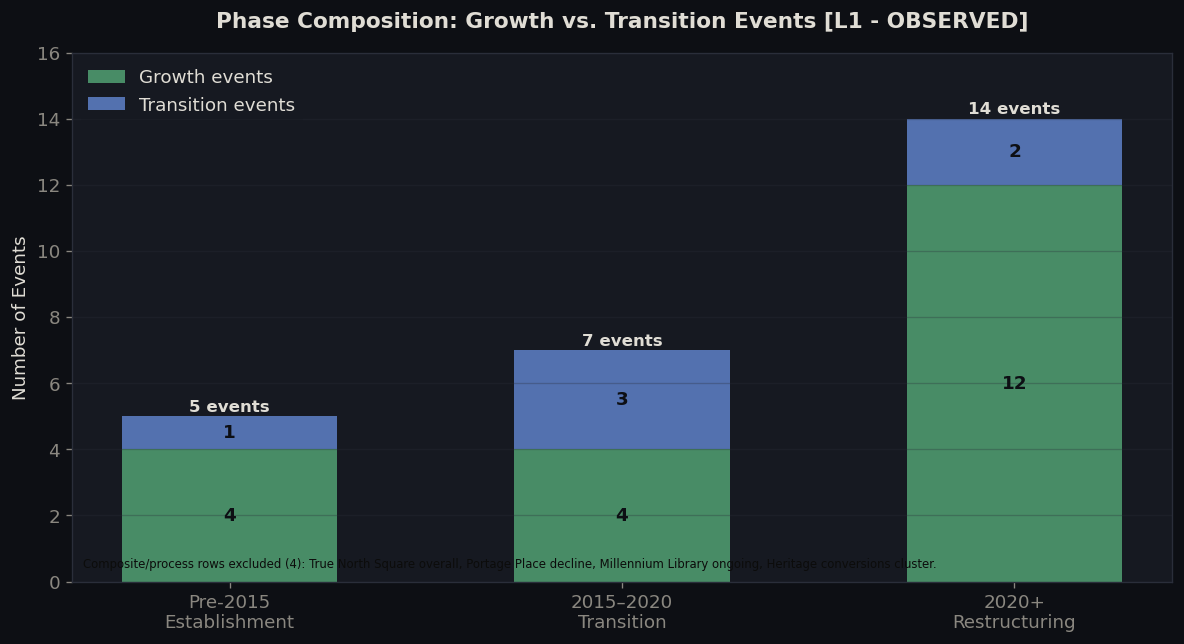

In [3]:
growth_vals, trans_vals, _ = compute_phase_composition(gantt)
phase_labels = ["Pre-2015\nEstablishment", "2015–2020\nTransition", "2020+\nRestructuring"]

fig, ax = plot_phase_composition(
    growth_vals=growth_vals, trans_vals=trans_vals,
    phase_labels=phase_labels,
    growth_color=GROWTH_C, transition_color=TRANS_C,
)
plt.show()

> **Why this matters for the general public:** A wave of "growth" projects sounds like good news, but a lot of that growth is conversion — old retail or office space being turned into housing or institutional use. That's different from the downtown coming back to what it used to be. It's becoming something new.

### 5.2 Retail Has Taken the Hardest Hit `[OBSERVED + RECONSTRUCTED]`

**Takeaway:** Comparing today to 2013, retail activity is down roughly 63%. Office-related businesses are down around 43%. Food and services is the most resilient group, and it's the one showing the clearest bounce-back after 2020.

<class 'pandas.core.frame.DataFrame'>
['Year', 'Licenses Issued', 'Licenses Closed', 'Net Change', 'Active Estimate', 'Vacancy Proxy Index', 'Confidence', 'Notes', 'idx']


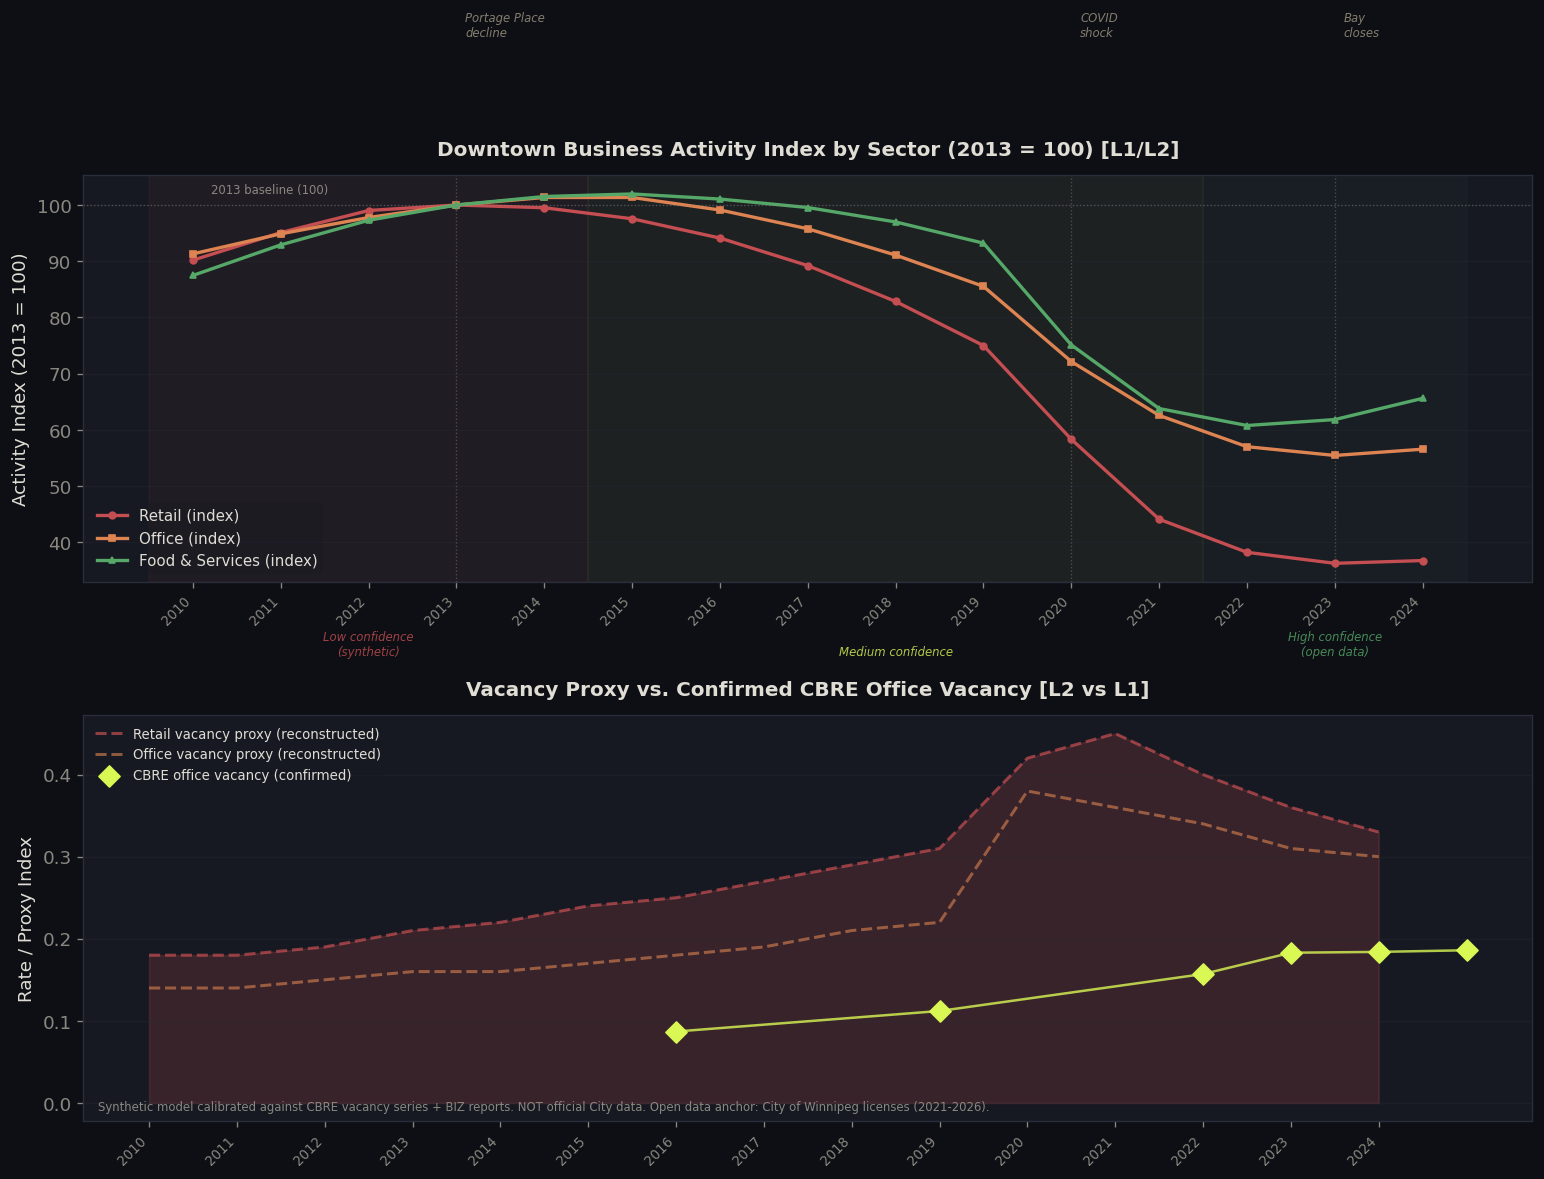

In [5]:
import importlib
import src.helpers as helpers
import matplotlib.pyplot as plt

importlib.reload(helpers)

file_path = "../data/Winnipeg_Synthetic_License_Model_2010_2024.xlsx"

retail, office, food, syn, base_year = helpers.prepare_business_activity_index_data(file_path)

print(type(retail))
print(retail.columns.tolist())

fig, axes = helpers.plot_business_activity_index(
    retail,
    office,
    food,
    syn,
    decline_color="#c44e52",
    transition_color="#dd8452",
    growth_color="#55a868",
    accent_color="#DAF854"
)

plt.show()

> **Why this matters for the general public:** Empty offices mean fewer workers going out for lunch, fewer people on the sidewalks, and less foot traffic for downtown businesses. But the crossover above the national average needs context — cities like Toronto and Calgary had more office vacancy to absorb coming out of the pandemic, so their numbers fell faster, not because their downtowns are healthier.

### 5.3 Office Vacancy Roughly Doubled in Nine Years `[OBSERVED]`

**Takeaway:** Downtown Winnipeg's office vacancy rate climbed from 8.7% in 2016 to 18.6% in 2025. In 2025 it crossed above the national average for the first time.

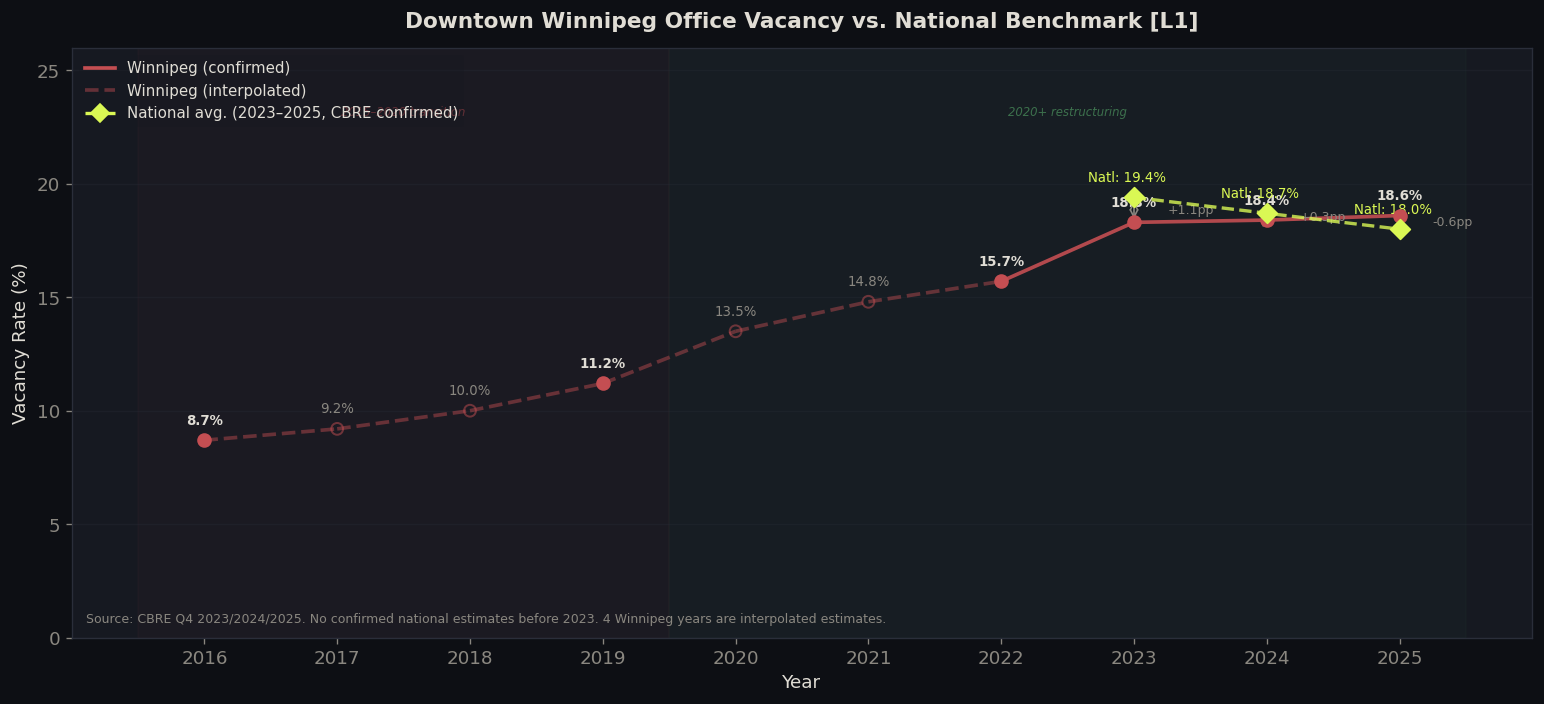

In [7]:
wpg_df, nat_df = prepare_vacancy_benchmark_data()

fig, ax = plot_vacancy_benchmark(
    wpg_df,
    nat_df,
    decline_color="#c44e52",
    growth_color="#55a868",
    accent_color="#DAF854"
)

plt.show()

> **Why this matters for the general public:** Empty offices mean fewer workers going out for lunch, fewer people on the sidewalks, and less foot traffic for downtown businesses. But the crossover above the national average needs context — cities like Toronto and Calgary had more office vacancy to absorb coming out of the pandemic, so their numbers fell faster, not because their downtowns are healthier.

### 5.4 A Lot of New Housing Is Being Built - But Not Yet Delivered `[OBSERVED + RECONSTRUCTED]`

**Takeaway:** Roughly 584 downtown housing units are already delivered. Another 800 to 950 are under construction or planned. Most of that will land in 2027 and 2028.

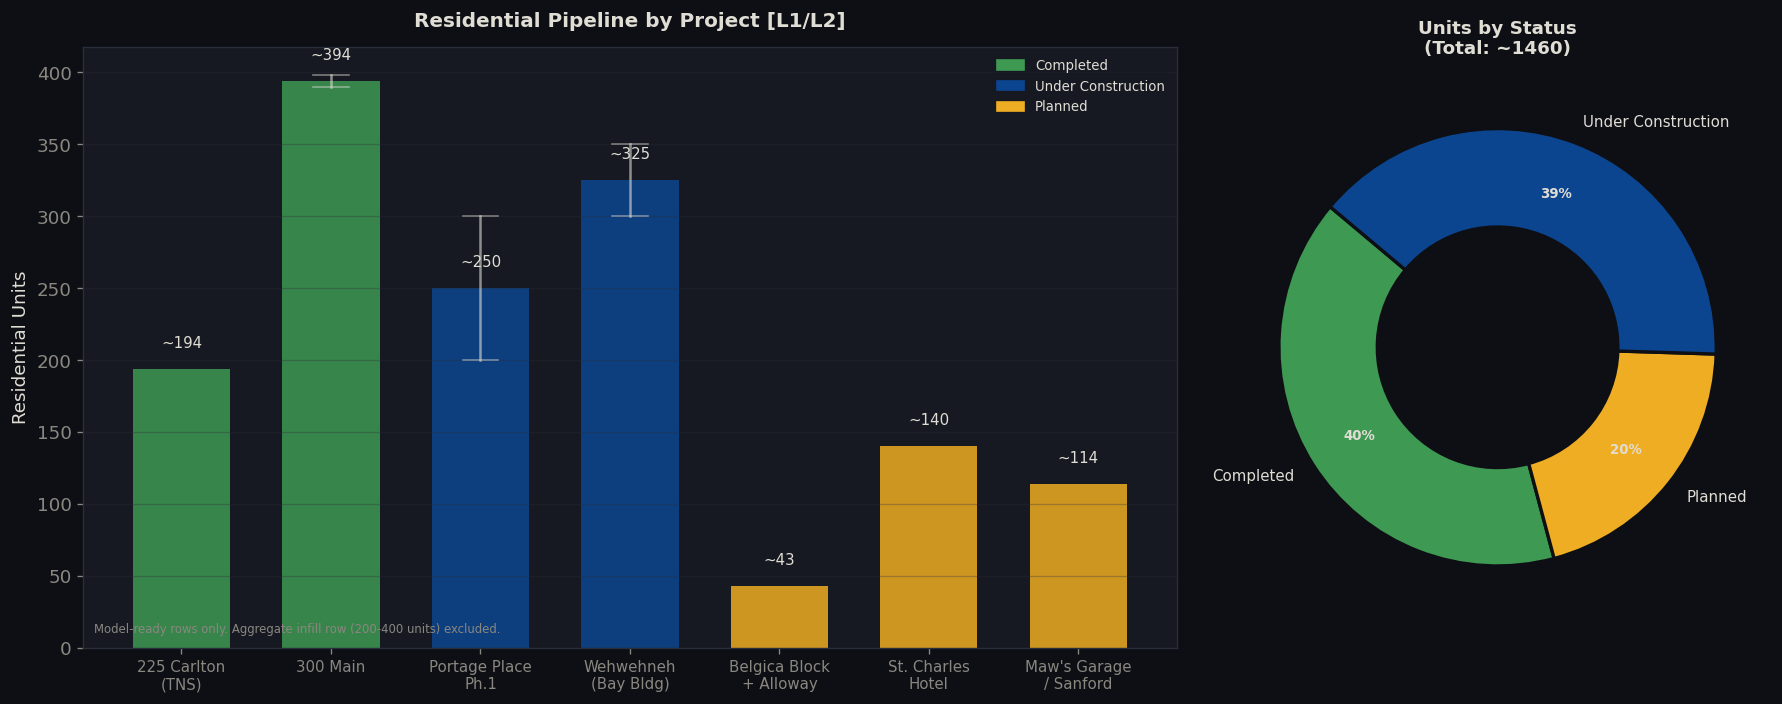

In [13]:
housing_model, short_labels = prepare_residential_pipeline_plot_data(housing)

fig, axes = plot_residential_pipeline(
    housing_model,
    short_labels,
    growth_color="#3e9953",
    transition_color="#0c458f",
    accent_color="#EEAD22"
)

plt.show()

> **Why this matters for the general public:** The reason downtown doesn't *feel* different yet is that most of the new residents haven't moved in yet. The buildings are going up - or are still on the drawing board - but the people haven't arrived. The street-level effect comes after the move-ins, not after the announcements.

### 5.5 The $2.3 Billion Figure, Broken Down `[OBSERVED]`

**Takeaway:** The widely reported $2.3 billion in downtown investment is real, but most of it is still unrealized - either under construction or committed but not yet built.

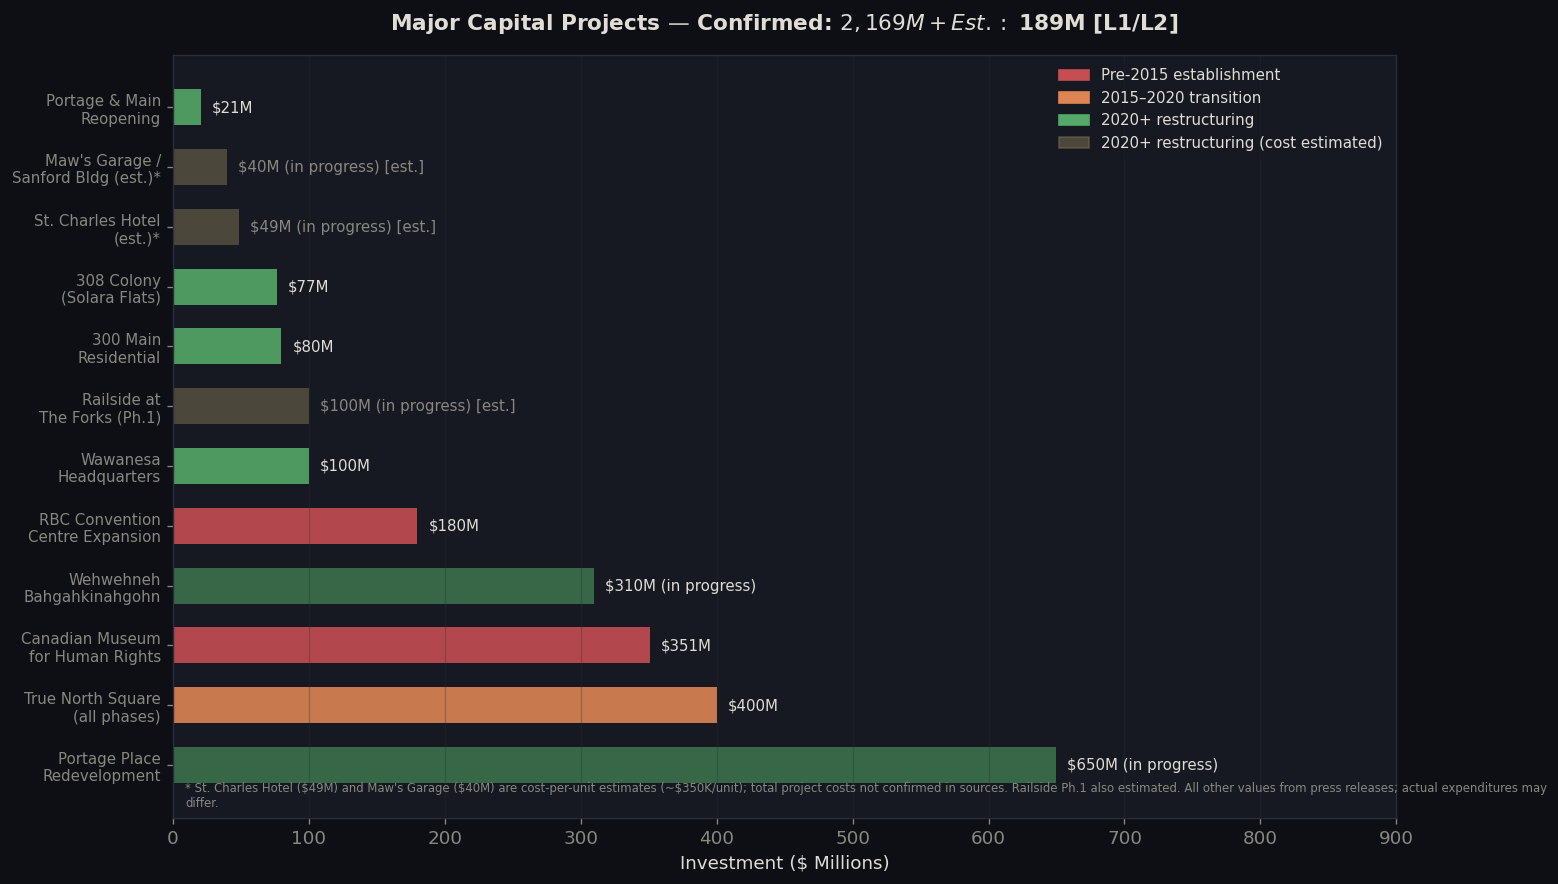

In [14]:
investment_df = prepare_investment_scale_data()

phase_colors = {
    "Pre-2015 establishment": "#c44e52",
    "2015–2020 transition": "#dd8452",
    "2020+ restructuring": "#55a868",
}

fig, ax = plot_investment_scale(investment_df, phase_colors)
plt.show()

> **Why this matters for the general public:** Headlines treat $2.3 billion as if it has already transformed downtown. It hasn't. Most of that money hasn't been spent yet, and the projects it represents haven't opened. The right way to read that number is as a promise of what might come, not a description of what already exists.

## 6. One Score That Pulls It All Together `[SCENARIO]`

To summarize everything in a single number, I built a **Downtown Health Score (DHS)** that combines five indicators: business stability, residential demand, investment pipeline, spatial anchoring, and vacancy distress.

**Important:** This is a scenario model, not a measurement. The weights reflect my judgement about relative importance, and the score would change if those weights changed. It is meant to summarize, not to predict.

In [15]:
dhs = compute_dhs(housing)

print(f"Business Stability:  {dhs['business_stability']}/100")
print(f"Residential Demand:  {dhs['residential_demand']}/100")
print(f"Investment Pipeline: {dhs['investment_pipeline']}/100")
print(f"Spatial Anchoring:   {dhs['spatial_anchoring']}/100")
print(f"Vacancy & Distress:  {dhs['vacancy_distress']}/10  (penalty)")
print("-" * 45)
print(f"DOWNTOWN HEALTH SCORE: {dhs['dhs']}/100  →  {dhs['band']}")

Business Stability:  42/100
Residential Demand:  92/100
Investment Pipeline: 78/100
Spatial Anchoring:   72/100
Vacancy & Distress:  8/10  (penalty)
---------------------------------------------
DOWNTOWN HEALTH SCORE: 63.0/100  →  Mixed/Transitional (50-64)


**Reading the score:** A DHS of 63 lands downtown in the **Mixed / Transitional** band. That matches everything else in this report: some indicators are strong (investment, housing pipeline), some are weak (vacancy, retail), and the overall picture is neither clearly good nor clearly bad.